# Description

Notebook to create a sin based dataset

In [147]:
verbose = False

In [148]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('Tesis')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
CURRENT_DIR = os.path.join(CURRENT_DIR, 'S-noise-gradient')
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [149]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from ucimlrepo import fetch_ucirepo 
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from IPython.display import display, clear_output
from tqdm import tqdm
import math
from scipy import stats
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import TSFEDL

# Locals
from utils import *
from dataset import BioFuelDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

In [150]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [151]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [152]:
class GeneralRegression(nn.Module):
    """
    Layers to transform any TSFEDL model into a regression model.

    Args:
        nn (Module): PyTorch module inheritance.
    """
    def __init__(self, in_features, output_size):
        super().__init__()
        self.output_size = output_size
        if not isinstance(self.output_size, int):
            self.output_size = output_size[0] * output_size[1]
        self.fc = nn.Linear(in_features, self.output_size)

    def forward(self, x):
        """
        Performs prediction on the input data in matrix format. Default function
        when calling the model().

        Args:
            x (pd.DataFrame): Input data for inference.

        Returns:
            torch.tensor: Tensor with calculated predictions.
        """
        out = self.fc(x)
        # out = out.view(len(out), self.output_size[0], self.output_size[1])
        return out

In [153]:
def add_gaussian_noise(df, columns, mean=0, std=0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


In [154]:
# fetch dataset 
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
df = air_quality.data.features
if verbose:
    display(f.tail())

In [155]:
date_time = pd.to_datetime(df.pop('Date').str.replace('/', '-')+' '+df.pop('Time'))
df.index = date_time
if verbose:
    display(df.tail())

# Original - No Noise

In [156]:
column_to_predict = 'PT08.S1(CO)'
# Remove rows where "NO2(GT)" column is less than 0
df = df[df[column_to_predict] >= 0]
X = df[[column_to_predict]].copy()
if verbose:
    display(X.tail())

In [157]:
X = X.asfreq('H')

In [158]:
X = X.interpolate(method='time')
y = X[column_to_predict].copy()

In [159]:
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
if verbose:
    display(X.tail())

In [160]:
y = X[column_to_predict].copy()
if verbose:
    display(y.tail())

In [161]:
_X_train, X_test, _y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    shuffle=False
)

X_train, X_val, y_train, y_val = train_test_split(
    _X_train, _y_train, 
    test_size=0.2,
    shuffle=False
)

window_size = int(len(X_train)*0.01)
future = 1
sliding_window_train = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=future, mode='range', cnn=True)
sliding_window_val = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=future, mode='range', cnn=True)

In [162]:
batch_size = 32
train_dataloader = DataLoader(sliding_window_train, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(sliding_window_val, batch_size=batch_size, shuffle=True)

In [163]:
for x, y in train_dataloader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([32, 1, 59])
torch.Size([32, 1])


In [164]:
# Parámetros del modelo
input_size = X_train.shape[1]
hidden_size = 1
num_layers = 32
output_size = 1

# Definir el criterio y el optimizador
criterion = nn.MSELoss()

# model = LSTMModel(input_size, hidden_size, output_size, num_layers)
general_regression = GeneralRegression(20, output_size)
model = TSFEDL.OhShuLih(input_size, general_regression, criterion)
model.to(device)

lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)

In [165]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=verbose)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=scheduler,
    batch_scheduler=None,
    patience=10,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, 'air_quality', 'lstm_air'),
)

In [166]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=verbose)
best_train_loss, best_val_loss

(0.0029998508979515973, 0.003694438126186875)

In [167]:
# trainer_basic.model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'lstm_air.pth')))

In [168]:
sliding_window_test = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=future, mode='range', cnn=True)
test_dataloader = DataLoader(sliding_window_test, batch_size=32, shuffle=False)

In [169]:
y_pred_test = trainer_basic.eval_dataloader(test_dataloader)
y_pred_test = [a.cpu().detach().numpy() for a in y_pred_test]
y_pred_test = np.concatenate(y_pred_test).ravel()
y_pred_test = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:879: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /opt/conda/conda-bld/pytorch_1699449183005/work/aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


In [188]:
y_test_real = scaler.inverse_transform(y_test.values.reshape(-1, 1)).ravel()
y_test_real = y_test_real[window_size+future-1:]
assert len(y_test_real) == len(y_pred_test)

In [189]:
mae = mean_absolute_error(y_test_real, y_pred_test)
mse = mean_squared_error(y_test_real, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_real - y_pred_test) / y_test_real)) * 100
r_squared = r2_score(y_test_real, y_pred_test)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  52.29715773328009
MAPE:  4.657811809549283
RMSE:  72.50055397049557
MSE:  5256.330326028741
R-squared:  0.8748035406463708


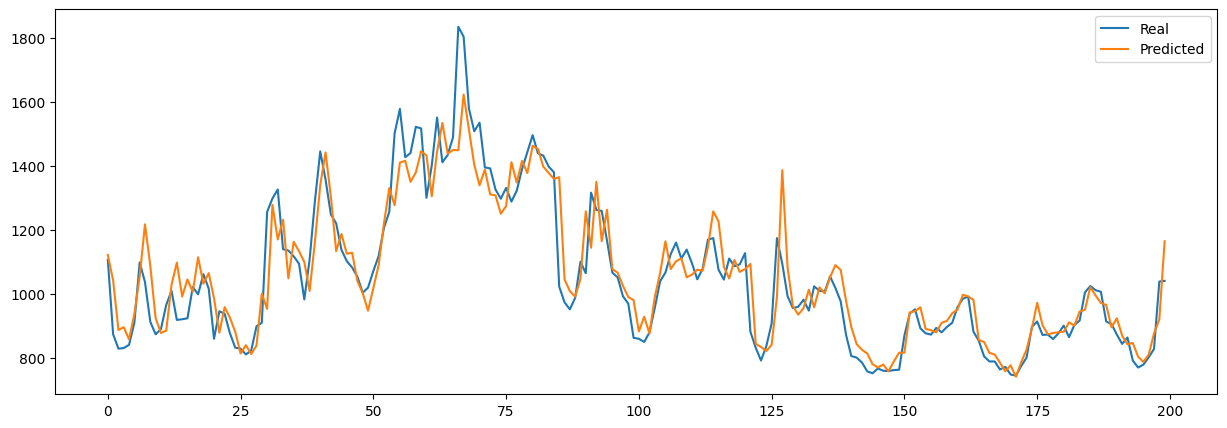

In [190]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_real[:200], label='Real')
plt.plot(y_pred_test[:200], label='Predicted')
plt.legend()
plt.show()

## ARIMA

In [126]:
column_to_predict = 'PT08.S1(CO)'
# Remove rows where "NO2(GT)" column is less than 0
df = df[df[column_to_predict] >= 0]
X = df[[column_to_predict]].copy()
if verbose:
    display(X.tail())

In [127]:
X = X.asfreq('H')

In [128]:
X = X.interpolate(method='time')
y = X[column_to_predict].copy()

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    shuffle=False
)

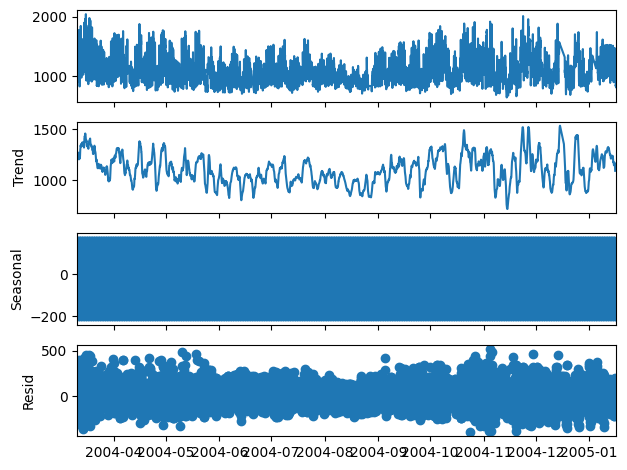

In [130]:
# Descomponer la serie temporal
decomposition = seasonal_decompose(X_train, model='additive')
decomposition.plot()
plt.show()

<Axes: >

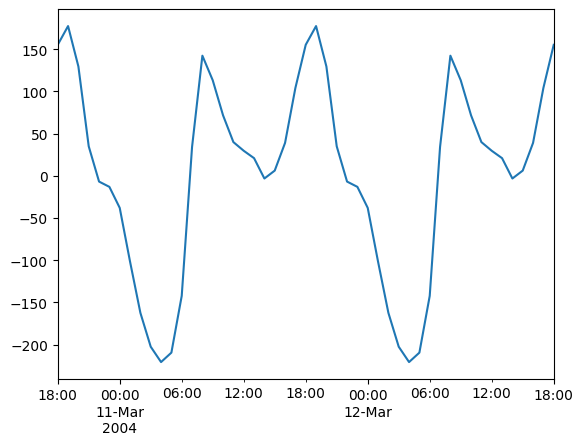

In [131]:
decomposition.seasonal.iloc[:49].plot()

In [132]:
# Prueba de estacionariedad (Dickey-Fuller)
result = adfuller(X_train.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print('Es estacionaria')

ADF Statistic: -8.430277507458875
p-value: 1.8782864287772004e-13
Es estacionaria


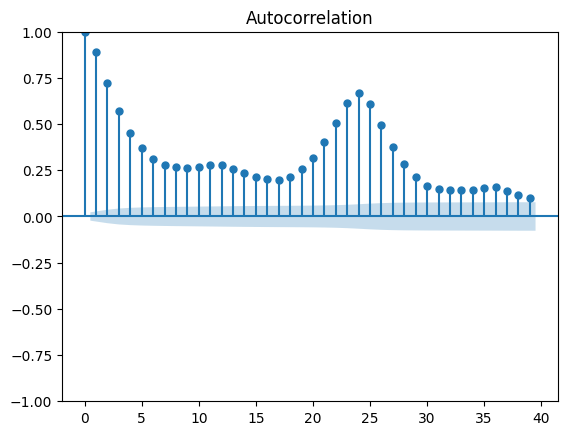

In [133]:
plot_acf(X_train)
plt.show()

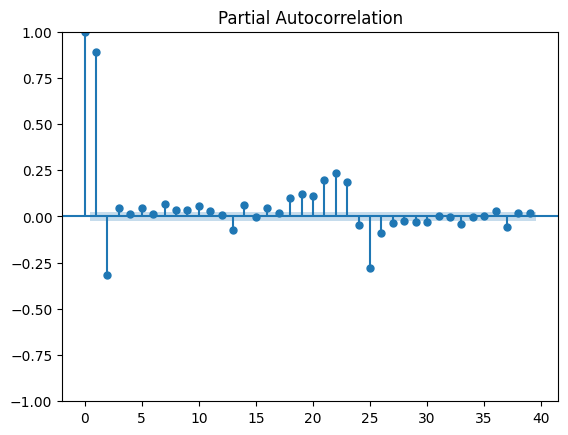

In [134]:
plot_pacf(X_train)
plt.show()

In [135]:
q = 24
p = 12
d = 0

In [136]:
model = ARIMA(X, order=(p, d, q))
model = model.fit()
print(model.summary())

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            PT08.S1(CO)   No. Observations:                 9357
Model:               ARIMA(12, 0, 24)   Log Likelihood              -54773.730
Date:                Tue, 04 Jun 2024   AIC                         109623.461
Time:                        10:25:21   BIC                         109894.928
Sample:                    03-10-2004   HQIC                        109715.655
                         - 04-04-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1103.0598     15.376     71.741      0.000    1072.924    1133.195
ar.L1          1.6671      0.107     15.537      0.000       1.457       1.877
ar.L2         -0.9197      0.266     -3.456      0.0

In [137]:
predictions = model.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, typ='levels')
predictions = pd.DataFrame(predictions.values, index=y_test.index, columns=['Prediction'])
predictions

,Prediction
2005-01-16 15:00:00,812.304904
2005-01-16 16:00:00,901.482687
2005-01-16 17:00:00,936.132100
2005-01-16 18:00:00,951.973197
2005-01-16 19:00:00,968.242545
...,...
2005-04-04 10:00:00,1211.010489
2005-04-04 11:00:00,1285.335566
2005-04-04 12:00:00,1110.023792
2005-04-04 13:00:00,1129.336589


In [141]:
y_test

2005-01-16 15:00:00     833.0
2005-01-16 16:00:00     877.0
2005-01-16 17:00:00     892.0
2005-01-16 18:00:00     899.0
2005-01-16 19:00:00    1008.0
                        ...  
2005-04-04 10:00:00    1314.0
2005-04-04 11:00:00    1163.0
2005-04-04 12:00:00    1142.0
2005-04-04 13:00:00    1003.0
2005-04-04 14:00:00    1071.0
Freq: H, Name: PT08.S1(CO), Length: 1872, dtype: float64

In [138]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
r_squared = r2_score(y_test, predictions)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  55.00938776333717
MAPE:  nan
RMSE:  77.48707403131405
MSE:  6004.2466419343455
R-squared:  0.8598897258337852


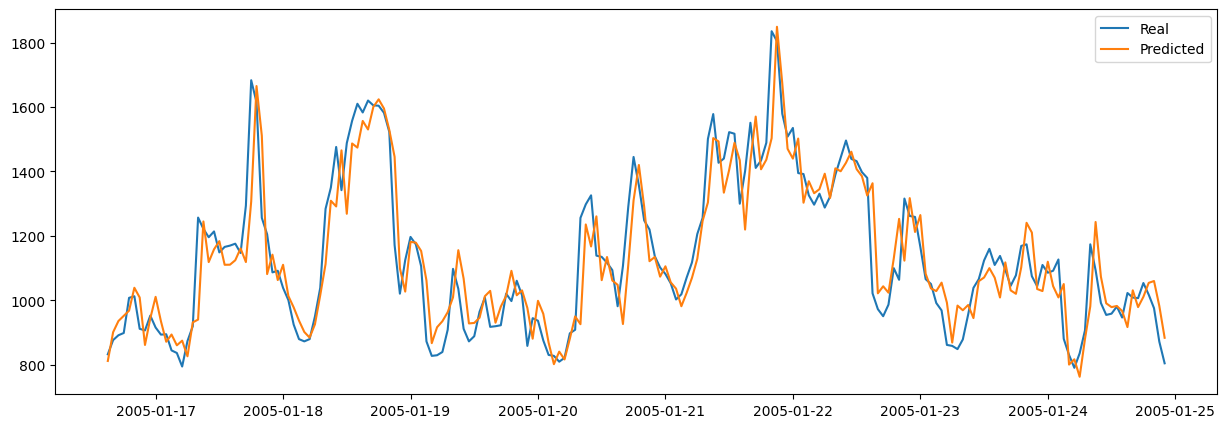

In [142]:
plt.figure(figsize=(15, 5))
plt.plot(y_test[:200], label='Real')
plt.plot(predictions[:200], label='Predicted')
plt.legend()
plt.show()